In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [8]:
X = df[['displacement']]
y = df['mpg']

print("Missing values in :", X.isnull().sum())
print("Missing values in mpg :", y.isnull().sum())

Missing values in : displacement    0
dtype: int64
Missing values in mpg : 0


In [9]:
data = df[['displacement', 'mpg']].dropna()

X = data[['displacement']]
y = data['mpg']

print("Feature:")
print(X.head())

print("\nTarget:")
print(y.head())

Feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


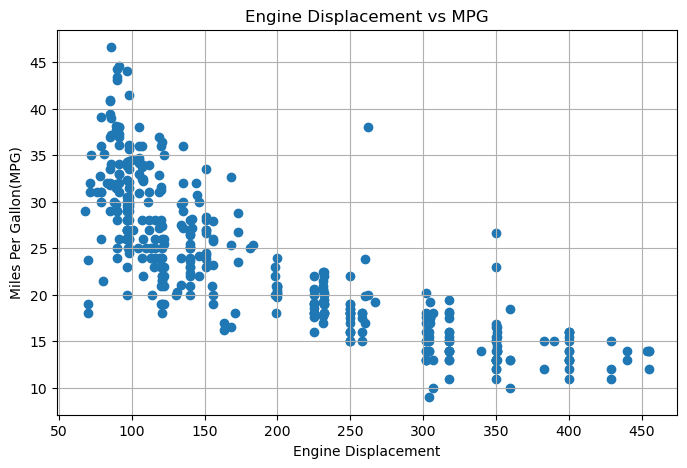

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(X,y)

plt.xlabel("Engine Displacement")    
plt.ylabel("Miles Per Gallon(MPG)")  
plt.title("Engine Displacement vs MPG")
plt.grid(True)
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 318
Testing samples: 80


In [16]:
#create regression model
linear_model=LinearRegression()

#train model
linear_model.fit(X_train, y_train)

#predict on test data
y_pred_linear = linear_model.predict(X_test)

In [18]:
#calculate mse
mse_linear = mean_squared_error(y_test, y_pred_linear)

#calculate r-squared
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression result")
print("-----------------")
print("MSE:", mse_linear)
print("R-squared:", r2_linear)

Linear Regression result
-----------------
MSE: 18.102543998358946
R-squared: 0.6633114869465595


In [23]:
results=[]

polynomial_models={}

#add linear regression results
results.append({
    'Model': "Linear Regression",
    'Degree': 1,
    'MSE': mse_linear,
    'R-squared': r2_linear
})

#try polynomial degree from 2-5
for degree in range(2,6):

    #create polynomial feature
    poly=PolynomialFeatures(degree=degree)

    #transform training and testing data
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    #create LR model
    poly_model=LinearRegression()

    #train poly regression model
    poly_model.fit(X_train_poly, y_train)

    #make prediction
    y_pred_poly=poly_model.predict(X_test_poly)

    #calculate evaluation metrics
    mse=mean_squared_error(y_test, y_pred_poly)
    r2=r2_score(y_test, y_pred_poly)
    
    # store result
    results.append({
    'Model': "Polynomial Regression",
    'Degree': degree,
    'MSE': mse,
    'R-squared': r2
    })

    #store model and polynomial transformer
    polynomial_models[degree] = {
        'poly': poly,
        'model': poly_model
    }

In [24]:
#convert result into DataFrame
results_df = pd.DataFrame(results)

#display results
results_df

,Model,Degree,MSE,R-squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230896,0.716721


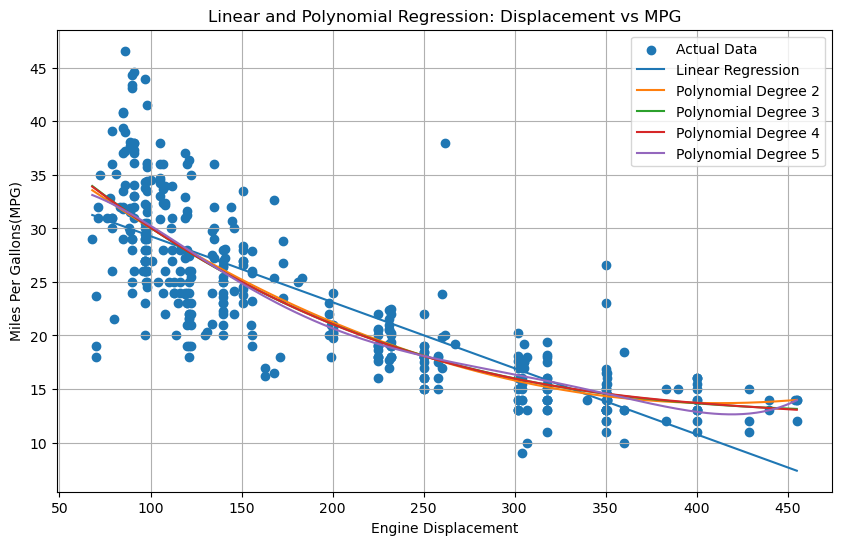

In [42]:
#create smooth X values for plotting
X_plot= pd.DataFrame({
    'displacement':np.linspace(
    X['displacement'].min(),
    X['displacement'].max(),
    300)    
})

#create figure
plt.figure(figsize=(10,6))

#plot actual data
plt.scatter(
    X['displacement'],
    y,
    label='Actual Data'
)

#plot LR
y_plot_linear = linear_model.predict(X_plot)

plt.plot(

    X_plot['displacement'],
    y_plot_linear,
    label='Linear Regression'
)

for degree in range(2,6):

    #retrieve stored transformer and model
    poly = polynomial_models[degree]['poly']
    poly_model = polynomial_models[degree]['model']

    #transform smooth X values
    X_plot_poly= poly.transform(X_plot)

    #predict
    y_plot_poly= poly_model.predict(X_plot_poly)

    #plot curve
    plt.plot(
        X_plot['displacement'],
        y_plot_poly,
        label=f'Polynomial Degree {degree}')

#plot formatting
plt.xlabel('Engine Displacement')
plt.ylabel('Miles Per Gallons(MPG)')
plt.title('Linear and Polynomial Regression: Displacement vs MPG')

plt.legend()
plt.grid(True)
plt.show()

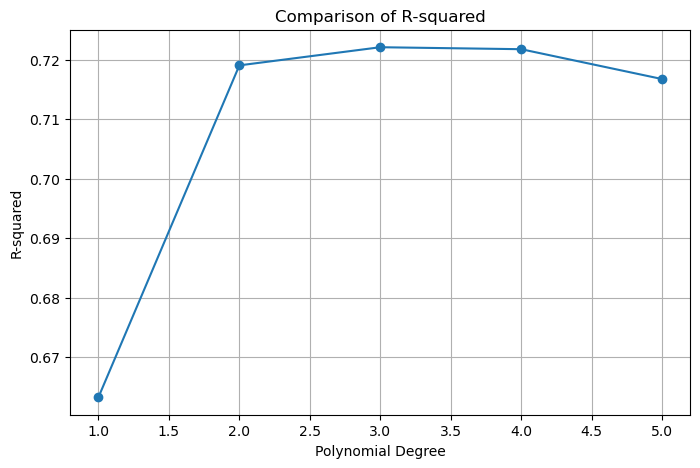

In [52]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df['Degree'],
    results_df['R-squared'],
    marker='o'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R-squared")
plt.title("Comparison of R-squared")

plt.grid(True)
plt.show()

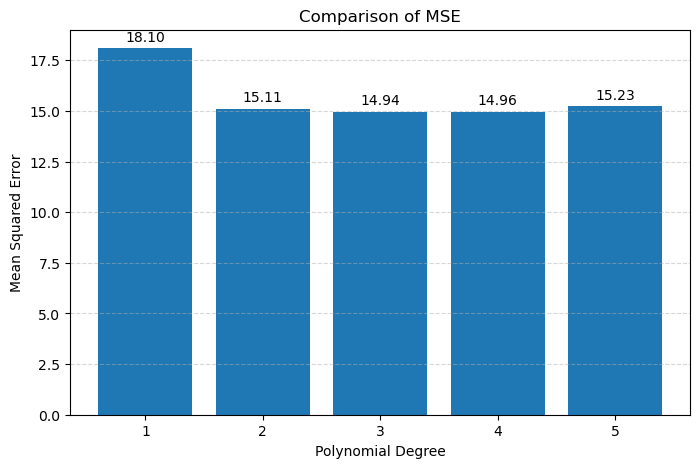

In [55]:
plt.figure(figsize=(8,5))

bars = plt.bar(results_df['Degree'].astype(str),results_df['MSE'])

plt.bar_label(bars, fmt='%.2f', padding=3)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Comparison of MSE")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()